<a href="https://colab.research.google.com/github/KofiSmith/Machine-learning-/blob/main/DL%20Study/Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import pandas as pd
import numpy as np
from glob import glob
import cv2
import matplotlib.pylab as plt

Mounted at /content/drive


In [ ]:
#Pulling images from Google drive and storing them in an array
data = []
file = "https://drive.google.com/drive/folders/1SrC0bvBQZtlbVfoj5cLPpWtNMdFhjjOK"
for image_class in file:
    for image in image_class:
        data.append(image)

In [ ]:

#Accessing image files from Google drive and storing them in an array with the glob function
Cats = glob('/content/drive/My Drive/Cat Dog/Cats/*')

Dogs = glob('/content/drive/My Drive/Cat Dog/Dogs/*')
len(Dogs), len(Cats)

(30, 30)

In [ ]:
img_mlp = plt.imread(Dogs[0])
img_cv2 = cv2.imread(Cats[0])
#Cats = img_mlp
#Cats = img_cv2

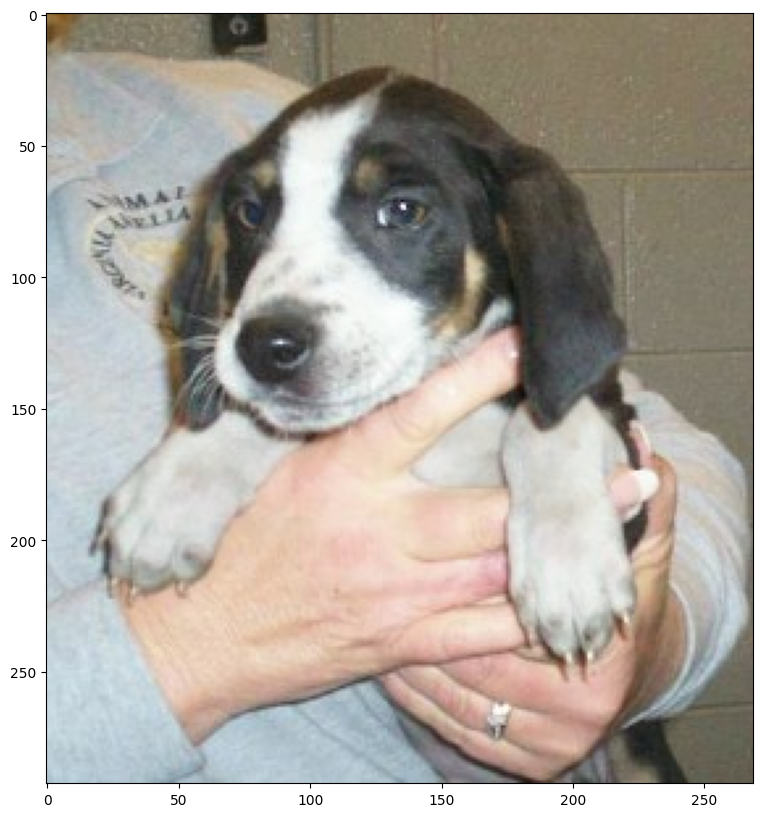

In [ ]:
#Displaying image the first cat image
fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(img_mlp)

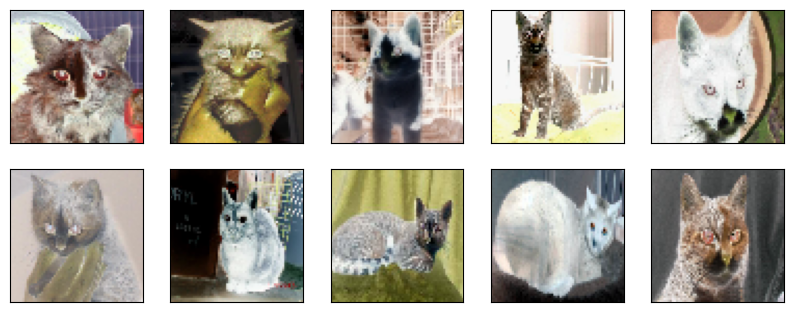

In [ ]:
plt.figure(figsize=(10,10))
target_size=(64,64)

for i in range(10):
   plt.subplot(5,5, i+1)
   img = cv2.imread(Cats[i])
   #Cat = cv2.resize(Cat[i], None, fx=0.25, fy=0.25)
   #Resize the image - dsize is calculated from fx and fy
   Cat = cv2.resize(img, target_size)
   Cat = cv2.bitwise_not(Cat)
   plt.xticks([])
   plt.yticks([])
   plt.grid(True)
   plt.imshow(Cat)
   #plt.xlabel(class_name[Cat])

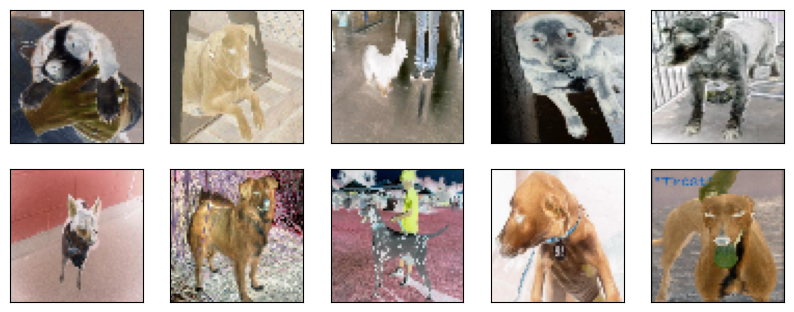

In [ ]:
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5, i+1)
    img = cv2.imread(Dogs[i])
    Dog = cv2.resize(img, target_size)
    Dog = cv2.bitwise_not(Dog)
    plt.xticks([])
    plt.yticks([])
    plt.grid(True)
    plt.imshow(Dog)

In [ ]:

#Arrays to contain the images
Cat_images = []
Dog_images = []


#Converting the image file paths to readable cv2 images a d appending them into the arrays
target_size = (64,64)

for i in range(len(Cats)):
    img = cv2.imread(Cats[i])
    Cat_images.append(cv2.resize(img, target_size))
for i in range(len(Dogs)):
    img = cv2.imread(Dogs[i])
    Dog_images.append(cv2.resize(img, target_size))

# Convert the lists to tf.data.Dataset objects, before they can be concatenated
Cat_dataset = tf.data.Dataset.from_tensor_slices(Cat_images)
Dog_dataset = tf.data.Dataset.from_tensor_slices(Dog_images)

#Merging the image arrays together as one array of image data
Cats_and_Dogs = Dog_dataset.concatenate(Cat_dataset).shuffle(1024)